Timothy - wants to get rid "best timing" within a year to sell an expensive house 

William Rodriguez - buyer - 2 people, "country" --> best timing & non-renovated 
buying & selling, costs back + little profit, socially responsible 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
#import the data from a csv-file
df = pd.read_csv('data/eda.csv') #, parse_dates = ['date']
df.shape # (21420, 21)
#make the dates pretty
df['date'] = pd.to_datetime(df.date, format='%Y-%m-%d')
df['yr_built'] = pd.to_datetime(df.yr_built, format='%Y')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21420 entries, 0 to 21419
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           21420 non-null  datetime64[ns]
 1   price          21420 non-null  float64       
 2   house_id       21420 non-null  int64         
 3   id             21420 non-null  int64         
 4   id.1           21420 non-null  int64         
 5   bedrooms       21420 non-null  float64       
 6   bathrooms      21420 non-null  float64       
 7   sqft_living    21420 non-null  float64       
 8   sqft_lot       21420 non-null  float64       
 9   floors         21420 non-null  float64       
 10  waterfront     19060 non-null  float64       
 11  view           21357 non-null  float64       
 12  condition      21420 non-null  int64         
 13  grade          21420 non-null  int64         
 14  sqft_above     21420 non-null  float64       
 15  sqft_basement  2096

In [3]:
df.duplicated().value_counts()
#no duplicates

False    21420
Name: count, dtype: int64

In [4]:
df.head(10)
#we still got an ID double, so...
df = df.drop(columns='id.1')

In [5]:
#and recast price 
df = df.astype({'price' : 'int64'})

<Axes: >

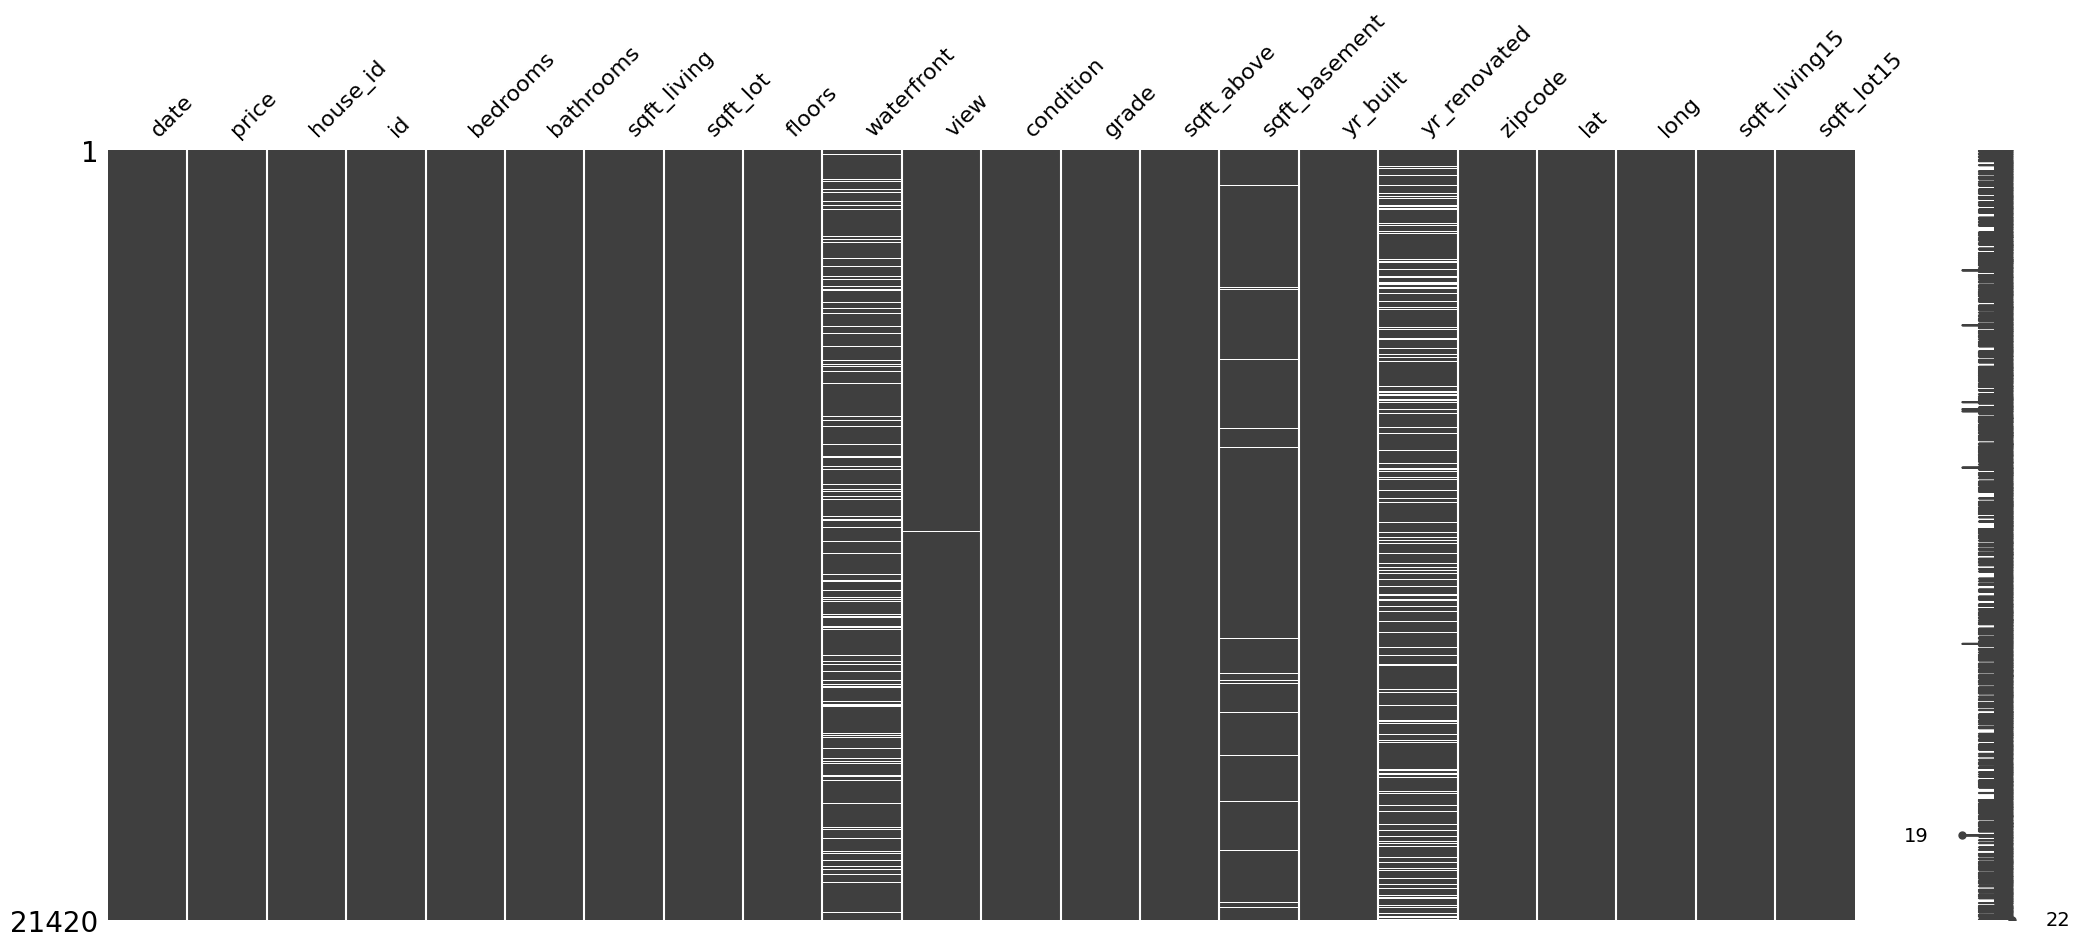

In [6]:
#then let's deal with missing values: 
import missingno as msno
df.isna().sum()
# --------------
#  so Waterfront has 2391
# view has only 63
# sqft_basement has 452 - more tricky! 
# yr renovated has 2848
# ------- rest is fine 
#msno.bar(df)
msno.matrix(df)
# ok, so they're all over the place 

Depending on the case, different cleaning methods could be considered: 
- consider "NA" as "unknown"
- try to estimate some values from the data

In detail: 
* Waterfront: are houses "nearby" waterfront or no? Set a radius (V2)
* View: can't be aggregated from other houses so leave it as "unknown" 
* Basement: can't be aggregated, so either "unknown" or "set 0" (unknown preferred)
* yr_renovated: "unknown" would be best, depending on client "not renovated" would be acceptable 

In [7]:
#df.info()
df.describe()

,date,price,house_id,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21420,2.142000e+04,2.142000e+04,21420.000000,21420.000000,21420.000000,21420.000000,2.142000e+04,21420.000000,19060.000000,...,21420.000000,21420.000000,20969.000000,21420,17609.000000,21420.00000,21420.000000,21420.000000,21420.000000,21420.000000
mean,2014-10-29 17:13:04.537815040,5.418614e+05,4.580940e+09,10803.537535,3.373950,2.118429,2083.132633,1.512804e+04,1.495985,0.007660,...,7.662792,1791.170215,292.086938,1971-02-04 02:18:41.344537800,838.805724,98077.87437,47.560197,-122.213784,1988.384080,12775.718161
min,2014-05-02 00:00:00,7.800000e+04,1.000102e+06,1.000000,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,...,3.000000,370.000000,0.000000,1900-01-01 00:00:00,0.000000,98001.00000,47.155900,-122.519000,399.000000,651.000000
25%,2014-07-22 00:00:00,3.249500e+05,2.123537e+09,5397.750000,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,0.000000,...,7.000000,1200.000000,0.000000,1952-01-01 00:00:00,0.000000,98033.00000,47.471200,-122.328000,1490.000000,5100.000000
50%,2014-10-17 00:00:00,4.505500e+05,3.904921e+09,10802.500000,3.000000,2.250000,1920.000000,7.614000e+03,1.500000,0.000000,...,7.000000,1560.000000,0.000000,1975-01-01 00:00:00,0.000000,98065.00000,47.572100,-122.230000,1840.000000,7620.000000
75%,2015-02-18 00:00:00,6.450000e+05,7.308900e+09,16213.250000,4.000000,2.500000,2550.000000,1.069050e+04,2.000000,0.000000,...,8.000000,2220.000000,560.000000,1997-01-01 00:00:00,0.000000,98117.00000,47.678100,-122.125000,2370.000000,10086.250000
max,2015-05-27 00:00:00,7.700000e+06,9.900000e+09,21597.000000,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,...,13.000000,9410.000000,4820.000000,2015-01-01 00:00:00,20150.000000,98199.00000,47.777600,-121.315000,6210.000000,871200.000000
std,NaN,3.675569e+05,2.876761e+09,6239.147834,0.925405,0.768720,918.808412,4.153080e+04,0.540081,0.087188,...,1.171971,828.692965,442.695597,NaN,4005.127226,53.47748,0.138589,0.140791,685.537057,27345.621867


In [8]:
df.head()

,date,price,house_id,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,221900,7129300520,1,3.0,1.00,1180.0,5650.0,1.0,NaN,...,7,1180.0,0.0,1955-01-01,0.0,98178,47.5112,-122.257,1340.0,5650.0
1,2014-12-09,538000,6414100192,2,3.0,2.25,2570.0,7242.0,2.0,0.0,...,7,2170.0,400.0,1951-01-01,19910.0,98125,47.7210,-122.319,1690.0,7639.0
2,2015-02-25,180000,5631500400,3,2.0,1.00,770.0,10000.0,1.0,0.0,...,6,770.0,0.0,1933-01-01,NaN,98028,47.7379,-122.233,2720.0,8062.0
3,2014-12-09,604000,2487200875,4,4.0,3.00,1960.0,5000.0,1.0,0.0,...,7,1050.0,910.0,1965-01-01,0.0,98136,47.5208,-122.393,1360.0,5000.0
4,2015-02-18,510000,1954400510,5,3.0,2.00,1680.0,8080.0,1.0,0.0,...,8,1680.0,0.0,1987-01-01,0.0,98074,47.6168,-122.045,1800.0,7503.0


## Data cleaning operations

In [9]:
# make a copy for cleaning
dfc = df.copy()

#make sqft_living & sqft_lot an int 
dfc = dfc.astype({'sqft_living' : int})
dfc = dfc.astype({'sqft_lot' : int})
dfc.info() # ok worked 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21420 entries, 0 to 21419
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           21420 non-null  datetime64[ns]
 1   price          21420 non-null  int64         
 2   house_id       21420 non-null  int64         
 3   id             21420 non-null  int64         
 4   bedrooms       21420 non-null  float64       
 5   bathrooms      21420 non-null  float64       
 6   sqft_living    21420 non-null  int64         
 7   sqft_lot       21420 non-null  int64         
 8   floors         21420 non-null  float64       
 9   waterfront     19060 non-null  float64       
 10  view           21357 non-null  float64       
 11  condition      21420 non-null  int64         
 12  grade          21420 non-null  int64         
 13  sqft_above     21420 non-null  float64       
 14  sqft_basement  20969 non-null  float64       
 15  yr_built       2142

In [10]:
#let's deal with "Waterfront" (V1) first: 
dfc['waterfront'].unique()
#ok fair, that's just "yes", "no" and "dunno"
#type(df['waterfront'][0])
dfc = dfc.astype({'waterfront': 'Int64'})
dfc['waterfront'].isna().sum() #2360
dfc = dfc.fillna({'waterfront':2}) #0
#dfc['waterfront'] = dfc['waterfront'].map({
#    0: 'no',
#    1: 'yes',
#    2: 'unknown'
#})
dfc['waterfront'].unique()

<IntegerArray>
[2, 0, 1]
Length: 3, dtype: Int64

In [11]:
type(dfc['view'][0])
dfc['view'].isna().sum() #63 missing values - we'll see
dfc = dfc.astype({'view': 'Int64'})
type(dfc['view'][0])
dfc['view'].unique() #... good...

<IntegerArray>
[0, <NA>, 3, 4, 2, 1]
Length: 6, dtype: Int64

In [12]:
#now to "yr_renovated"... 
dfc = dfc.astype({'yr_renovated':'Int64'})
dfc = dfc.fillna({'yr_renovated':2})
#ok let's brute force it: 

conditions = [ 
    (dfc['yr_renovated'] == 2),
    (dfc['yr_renovated'] == 0),
    (dfc['yr_renovated'] < 19500),
    (dfc['yr_renovated'] >=19500) & ((dfc['yr_renovated'] < 19700)),
    (dfc['yr_renovated'] >=19700) & ((dfc['yr_renovated'] < 19900)),
    (dfc['yr_renovated'] >=19900) & ((dfc['yr_renovated'] < 20100)),
    (dfc['yr_renovated'] >=20100) & ((dfc['yr_renovated'] < 20140)),
    (dfc['yr_renovated'] >=20140 )
]
choices = [
    '0_unknown',
    '0_unrenovated',
    '1_fifties',
    '2_seventies',
    '3_nineties',
    '4_twotens',
    '5_twoforteen',
    '6_recently'
]

dfc['renovation_status'] = np.select(conditions, choices, default='error')
dfc['renovation_status'].unique()


array(['0_unrenovated', '4_twotens', '0_unknown', '5_twoforteen',
       '3_nineties', '2_seventies', '6_recently', '1_fifties'],
      dtype=object)

In [13]:
dfc = dfc.astype({'view':'Int64'})
dfc['view'].unique()

<IntegerArray>
[0, <NA>, 3, 4, 2, 1]
Length: 6, dtype: Int64

### Understanding the data

<Axes: ylabel='Frequency'>

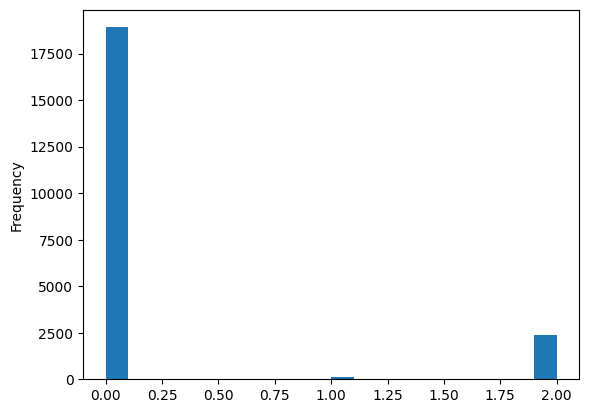

In [14]:
dfc['waterfront'].plot(kind='hist', bins=20)
#so hardly anything has actual waterfront

In [15]:
dfc.query('waterfront == 1').value_counts()
#only 141 to go with ... that's really low... 
dfc.query('waterfront == 1 and grade > 8') #at least 79
dfc.query('waterfront == 1 and grade > 8 and bedrooms >=3 and bedrooms <=8').value_counts() #ok cool that's still 70. 


date        price    house_id    id     bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  condition  grade  sqft_above  sqft_basement  yr_built    yr_renovated  zipcode  lat      long      sqft_living15  sqft_lot15  renovation_status
2014-05-09  2400000  724069059   4010   3.0       2.25       3000         11665     1.5     1           4     3          11     3000.0      0.0            2001-01-01  2             98075    47.5884  -122.086  3000.0         15959.0     0_unknown            1
2014-11-18  3600000  4114601570  2863   3.0       3.25       5020         12431     2.0     1           4     3          10     3420.0      1600.0         1941-01-01  20020         98144    47.5925  -122.287  3680.0         12620.0     4_twotens            1
2014-12-30  3300000  3625059152  18186  3.0       3.25       4220         41300     1.0     1           4     4          11     2460.0      1760.0         1958-01-01  19870         98008    47.6083  -122.110  3810.0         3040

,date,price,house_id,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,renovation_status
15,2015-01-24,650000,9297300055,16,4.0,3.00,2950,5000,2.0,0,...,1980.0,970.0,1979-01-01,0,98126,47.5714,-122.375,2140.0,4000.0,0_unrenovated
21,2014-08-26,2000000,2524049179,22,3.0,2.75,3050,44867,1.0,0,...,2330.0,720.0,1968-01-01,0,98040,47.5316,-122.233,4110.0,20336.0,0_unrenovated
58,2014-08-27,951000,7922800400,59,5.0,3.25,3250,14342,2.0,0,...,3250.0,0.0,1968-01-01,2,98008,47.5880,-122.116,2960.0,11044.0,0_unknown
60,2014-12-10,650000,1516000055,61,3.0,2.25,2150,21235,1.0,2,...,1590.0,560.0,1959-01-01,0,98166,47.4336,-122.339,2570.0,18900.0,0_unrenovated
152,2015-04-01,2250000,7855801670,154,4.0,3.25,5180,19850,2.0,0,...,3540.0,1640.0,2006-01-01,0,98006,47.5620,-122.162,3160.0,9750.0,0_unrenovated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21152,2014-08-22,1490000,8835770170,21329,5.0,6.00,6880,279968,2.0,0,...,4070.0,2810.0,2007-01-01,0,98045,47.4624,-121.779,4690.0,256803.0,0_unrenovated
21313,2014-06-17,1560000,9468200109,21490,3.0,3.50,4360,6240,2.0,0,...,2960.0,1400.0,2008-01-01,0,98103,47.6791,-122.354,1920.0,3910.0,0_unrenovated
21347,2015-02-19,338500,8902000201,21524,3.0,2.25,1333,1470,3.0,0,...,1333.0,0.0,2009-01-01,2,98125,47.7058,-122.302,1360.0,1680.0,0_unknown
21348,2015-01-13,1880000,715010530,21525,5.0,3.50,4410,13000,2.0,0,...,2920.0,1490.0,2014-01-01,0,98006,47.5382,-122.111,5790.0,12969.0,0_unrenovated


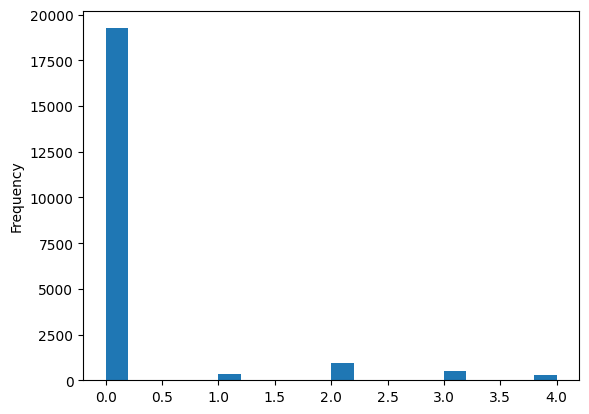

In [16]:
dfc['view'].plot(kind='hist', bins=20)
dfc.query('view >= 3').value_counts() # well at least that's 801
dfc.query('view >=3')

<Axes: xlabel='condition', ylabel='price'>

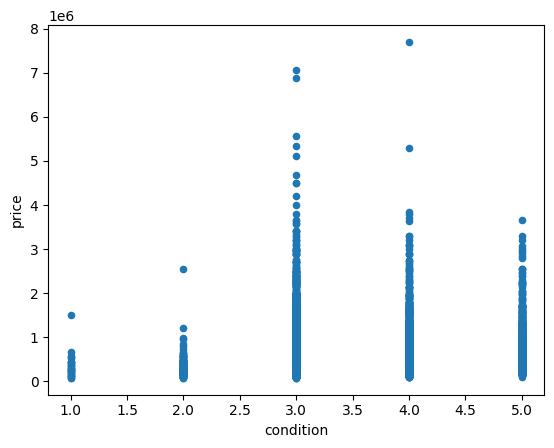

In [17]:
df['condition'].unique() # [1, 2, 3, 4, 5]
#since smaller numbers have lower prices, condition is read "rising"
df.plot(kind='scatter', x='condition', y='price')
#but this shows something really interesting - condition doesn't determine price!

In [18]:
df['floors'].unique()
#df.plot(kind='scatter', x='floors', y='price')
#weird... floors don't correlate neatly with price either! ... huh 

array([1. , 2. , 1.5, 3. , 2.5, 3.5])

<Axes: xlabel='grade', ylabel='price'>

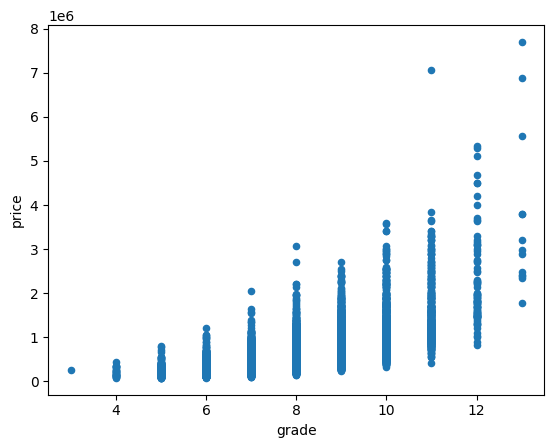

In [19]:
sorted(df['grade'].unique())
#ok so from 3 to 13
df.plot(kind='scatter', x='grade', y='price')
#that one does though ... but not really neatly and directly... 

<Axes: xlabel='view', ylabel='price'>

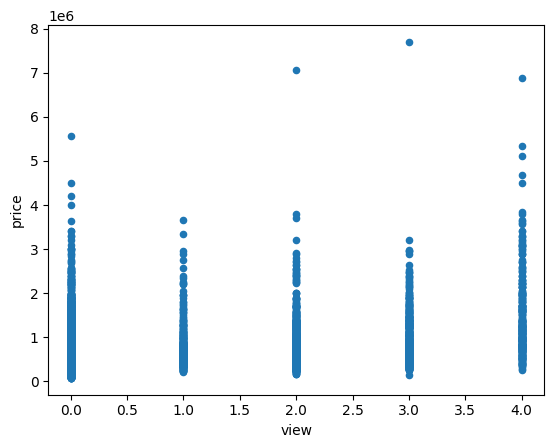

In [20]:
df['view'].unique() #[ 0., nan,  3.,  4.,  2.,  1.]
#the heck? ... let's say those WOULD be quality (I am allowed to make stuff up )

#let's check this then.. 
df.plot(kind='scatter', x='view', y='price')
#wow! Nothing to see... wtf? 

<Axes: xlabel='waterfront', ylabel='price'>

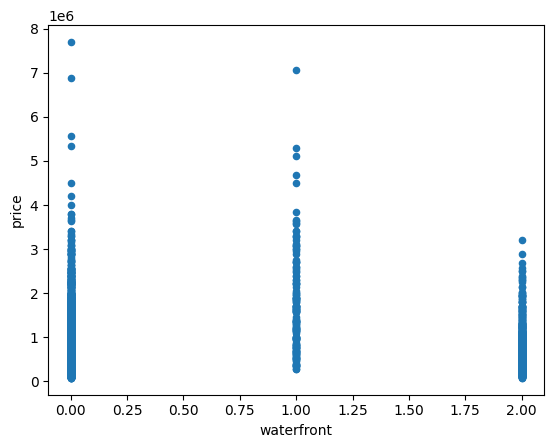

In [21]:
dfc.plot(kind='scatter', x='waterfront', y='price')
#huh!! nothing really useful there EITHER

Or do better - waterfront could be calculated "by the neighbor" .. fair ... 

for Renovated: 
"Price per sqf living" - good measure for quality 
- and - "bigger than the rest" - good measure (price / sqft)
- and just divide "my sqft" through "yoursqft" and make smaller 1, bigger 1, 

- sqft living / lot - large garden 




<Axes: ylabel='Frequency'>

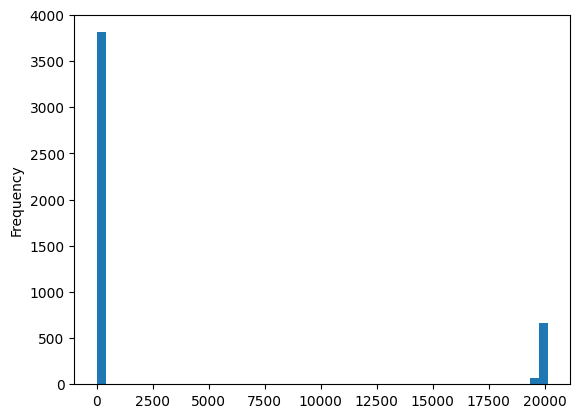

In [22]:
dfc['yr_renovated'].isna().sum() #3811
dfc.query('yr_renovated == 0.0')['yr_renovated'].value_counts() #16869
# in this case, we'll treat "unknown" as "not renovated" - as we can only work with houses which we know were renovated 
dfcr = dfc.copy()

dfcr = dfc.query('yr_renovated != 0.0') #4551 only 4551 known renovated properties available
dfcr['yr_renovated'].plot(kind='hist', bins=50)
#dfc['yr_renovated'] = dfc['yr_renovated'].fillna(0)
#dfc['yr_renovated'].isna().sum() # removed the Null 
#dfc['yr_renovated'] = dfc.yr_renovated.astype('string')
#dfc['yr_renovated'] =dfc['yr_renovated'].str.strip('0.0')
#dfc['yr_renovated'].isna().sum()



<Axes: xlabel='renovation_status', ylabel='price'>

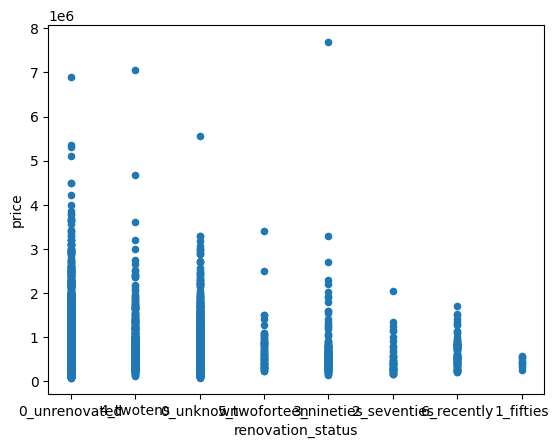

In [23]:
dfc.plot(kind='scatter', x='renovation_status', y='price')
#ok that is SEVERELY interesting ... 

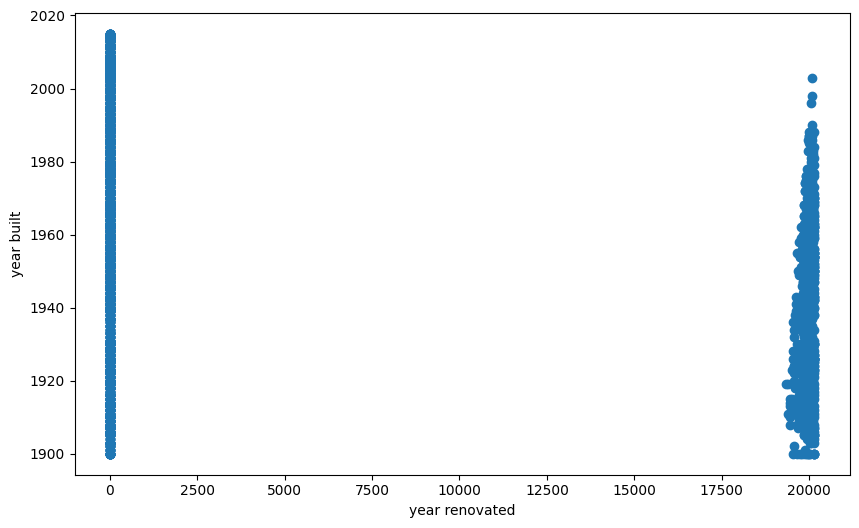

In [24]:
fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(
    x=dfcr.yr_renovated,
    y=dfcr.yr_built,
)

ax.set_xlabel('year renovated')
ax.set_ylabel('year built')

plt.show()
#wait... that's odd... there are houses LAST renovated... in the 30s??? 

ok ... this is WEIRD 
this data means that there were houses SOLD which were built in the 30s and last renovated in the 50s and SOLD! the one is last renovated in the 40s buildt in the 20s...
something fishy, but it's interesting! 

--- I want to check this using price categories.. 
--- grade would actually work better ... Ha! That has to work ... 

So that would have to show us something

In [25]:
dfc['price'].max() #7700000
dfc['price'].min() #78000
dfc['price'].median() #450550.0
dfc['price'].mean() #541861
#fig, ax = plt.subplots(figsize=(10,5))
#ax.boxplot([dfc['price']])
#plt.show()

np.float64(541861.4281512605)

<Axes: xlabel='yr_renovated', ylabel='price'>

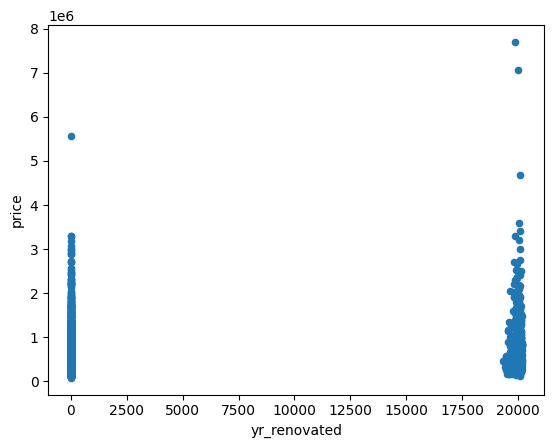

In [26]:
dfcr.plot(kind='scatter', x='yr_renovated', y='price')

<Axes: ylabel='Frequency'>

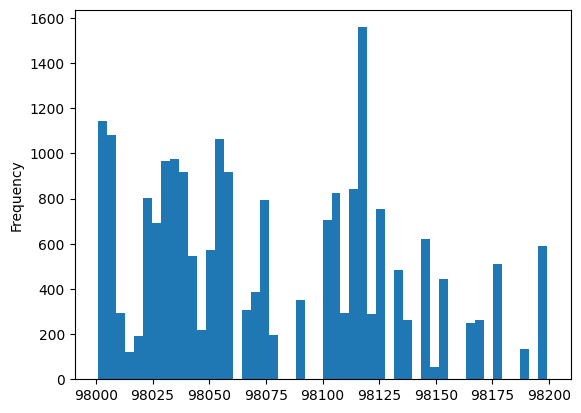

In [27]:
dfc['zipcode'].nunique()
dfcx = dfc.groupby('zipcode')
dfcx['zipcode'].plot(kind='hist', bins=10)
dfc['zipcode'].plot(kind='hist', bins=50)

#make "more or less populated" categories

In [28]:
type(dfc['yr_built'][0]) #- ok, it's an int

pandas._libs.tslibs.timestamps.Timestamp

In [29]:
dfc['yr_renovated'].isna().sum()
dfc['yr_renovated'] = dfc['yr_renovated'].fillna(7)
dfc['yr_renovated'].isna().sum()



np.int64(0)

Ok, so what's in there? 

1. doppelte Verkäufe: ist eigentlich nur der LETZTE Kauf relevant? 
2. das ist NUR die Vergangenheit: KEINE zum Verkauf stehenden Objekte 
-- du kannst sagen "wo wird viel verkauft" (wovon?)
3. eigentlich müsste man "Stadt" und "Land" hinzufügen --- man hat "Zip" 
4. 

Aufgabenstellung: 
"Seller" - er möchte "Gewinn" machen - was für ein Haus hat der? HÄ? 


High budget, wants to show off, timing within a month, waterfront, renovated, high grades, resell within 1 year

Has several houses, some in bad neighborhoods, willing to evict people, timing?, big returns, open for renovations
-- "bad neighborhoods" - niedriger Kaufpreis (ggf. zusatzinfo Einkommen) - "big returns" - "open for renovations"


- ok, Price is "it was sold as that"
- but - are all these houses "for" sale? 

ok - "if these houses were for sale" - recommend "that one" - as if they were for sale 

how do you know "central" or "outskirt" - from just THIS dataset? 
unless mapping is done? 

- recommend "best price" and "season" ---> for the whole "timing" bunch 
... so get "seasons" out of the data? 
- what about "trends" - can we do "market conditions"? 

SO ... I need to make "seasonality" as a category 
I do "hypotheses" - "buying in winter is cheaper" ...??? 

Take "seattle" as A POINT - I can do "distance" - latitude and longitude 

Invests in historical houses, best neighborhoods, high profits, best timing within a year, should renovate?
* zipcodes with high prices 
* a historical house (which is rather cheap)
* when to sell (a historical house or general?)
* does it get better with renovation? 

Unlimited Budget, 4+ bathrooms or smaller house nearby, big lot (tennis court & pool), golf, historic, no waterfront

* expensive 
* historic 


Jennifer Montgomery: 

High budget, wants to show off, timing within a month, waterfront, renovated, high grades, resell within 1 year

* expensive house (whatever show off means )
* "during a month" timing? seasonality more specific 
* "renovated" 
* high grades - easy 
---> resell within a year maybe look for a trend 

In [30]:
dfc.head()

,date,price,house_id,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,renovation_status
0,2014-10-13,221900,7129300520,1,3.0,1.00,1180,5650,1.0,2,...,1180.0,0.0,1955-01-01,0,98178,47.5112,-122.257,1340.0,5650.0,0_unrenovated
1,2014-12-09,538000,6414100192,2,3.0,2.25,2570,7242,2.0,0,...,2170.0,400.0,1951-01-01,19910,98125,47.7210,-122.319,1690.0,7639.0,4_twotens
2,2015-02-25,180000,5631500400,3,2.0,1.00,770,10000,1.0,0,...,770.0,0.0,1933-01-01,2,98028,47.7379,-122.233,2720.0,8062.0,0_unknown
3,2014-12-09,604000,2487200875,4,4.0,3.00,1960,5000,1.0,0,...,1050.0,910.0,1965-01-01,0,98136,47.5208,-122.393,1360.0,5000.0,0_unrenovated
4,2015-02-18,510000,1954400510,5,3.0,2.00,1680,8080,1.0,0,...,1680.0,0.0,1987-01-01,0,98074,47.6168,-122.045,1800.0,7503.0,0_unrenovated


## How to segment houses 
- first, check price ranges (independent of time)
-- look at the curve and cut some pieces of it 
(using the statistical measures of course)

- then, make size bins (depending on client): if we want to look at the features at all, check them 

- then, the years when houses were buildt can be categorized into several things 

- if it's bigger than the "around" it's "larger than average" 
... equal neighborhood? ... surrounded by many houses where the relation is close to 1

## Get a feel for the dataset

<Axes: ylabel='Frequency'>

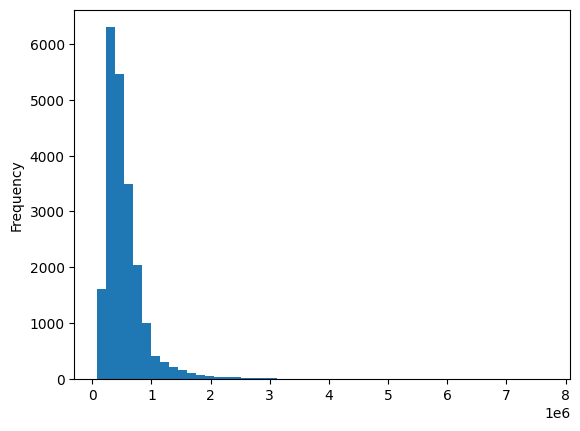

In [31]:
dfc.price.max()
dfc.price.min()
dfc.price.plot(kind='hist', bins=50)

dfc.grade.

<Axes: ylabel='Frequency'>

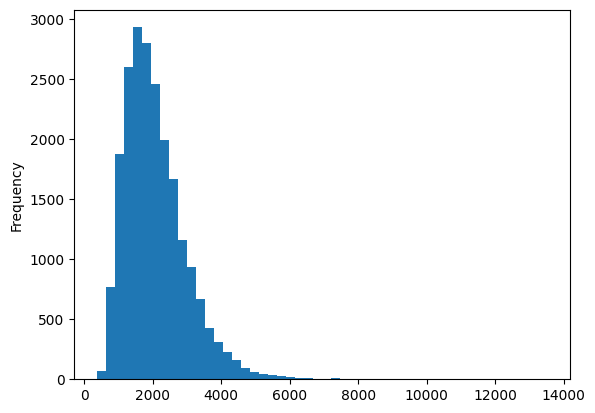

In [32]:
dfc.sqft_living.max() #13540.0
dfc.sqft_living.min() #370.0
dfc.sqft_living.plot(kind='hist', bins = 50)

<Axes: ylabel='Frequency'>

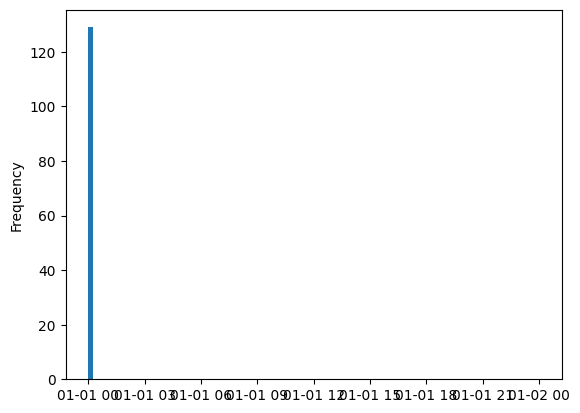

In [33]:
dfc.yr_built.min() #oldest ist 1900
dfc.yr_built.max() #youngest is NEW, 2015
dfc.yr_built.plot(kind='hist', bins=100)

<Axes: xlabel='zipcode'>

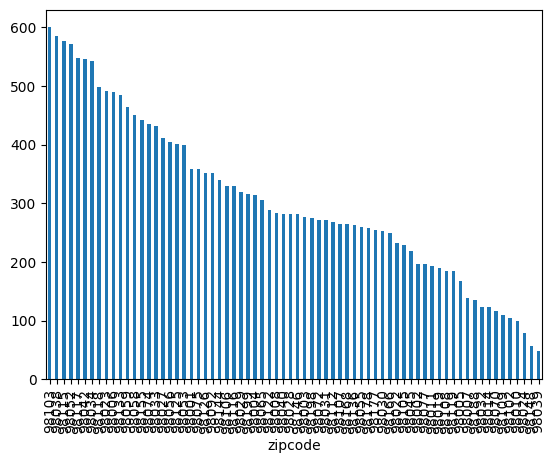

In [34]:
#dfc.zipcode.plot(kind='hist', bins=50)
#ToDo: do sorted 
list = dfc.zipcode.value_counts()
listsort = list.sort_values()
list.plot(kind='bar')
# 500, #350, #250, 150, (50)

#500, 530, 150 (take 50 for good measure)
#you have to keep in mind - "lots of houses" doesn't mean CROWDED 
#how big is the AREA matters and how many PEOPLE live in it 
#BUT we're taking this as a proxy 

<Axes: ylabel='Frequency'>

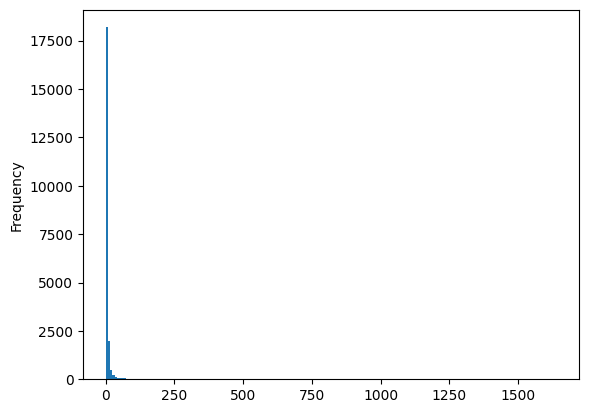

In [35]:
#let's get one better: 
dfc = dfc.eval('gardenratio = sqft_lot / sqft_living')
#make a column stating the ratio between living area and lot 
dfc.gardenratio.plot(kind='hist', bins=200)


In [36]:
#ok, let's do that again: 
dfc[['sqft_living', 'sqft_lot']].describe()
#ratio between sqft lot and living 

,sqft_living,sqft_lot
count,21420.000000,2.142000e+04
mean,2083.132633,1.512804e+04
std,918.808412,4.153080e+04
min,370.000000,5.200000e+02
25%,1430.000000,5.040000e+03
50%,1920.000000,7.614000e+03
75%,2550.000000,1.069050e+04
max,13540.000000,1.651359e+06


In [37]:
#dfc.view.value_counts().plot(kind='hist', bins=100)

<Axes: ylabel='Frequency'>

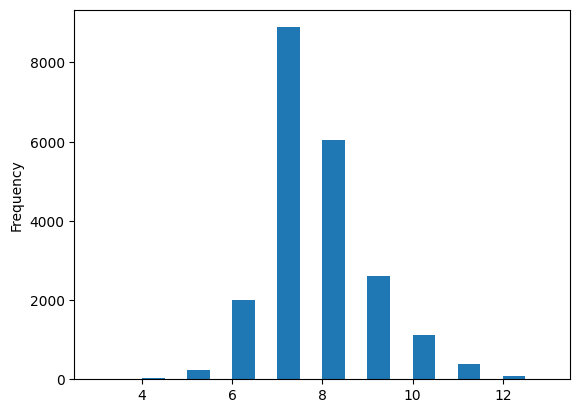

In [38]:
dfc.grade.plot(kind='hist', bins=20)
#most houses are "okish"

<Axes: ylabel='Frequency'>

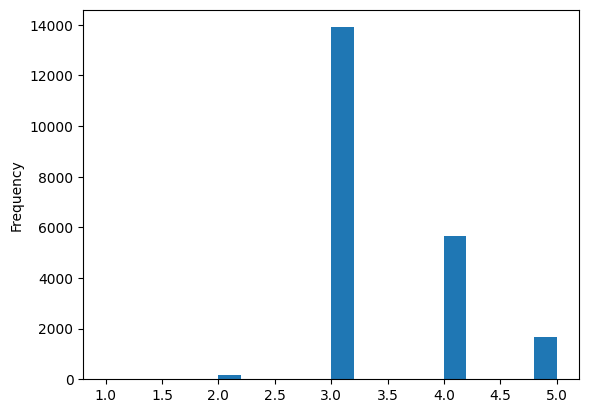

In [39]:
dfc['condition'].plot(kind='hist', bins=20)
#marketing has happened...? 

In [40]:
dfc[['price', 'lat', 'long']].corr()
#lat "minus" it's more north
#lat "plus" it's more south 

,price,lat,long
price,1.000000,0.306439,0.019826
lat,0.306439,1.000000,-0.136227
long,0.019826,-0.136227,1.000000


group by zipcode 
and then also you could give it a different color by zipcode 

Bins: Bedrooms "small" - "Medium" 

<Axes: ylabel='Frequency'>

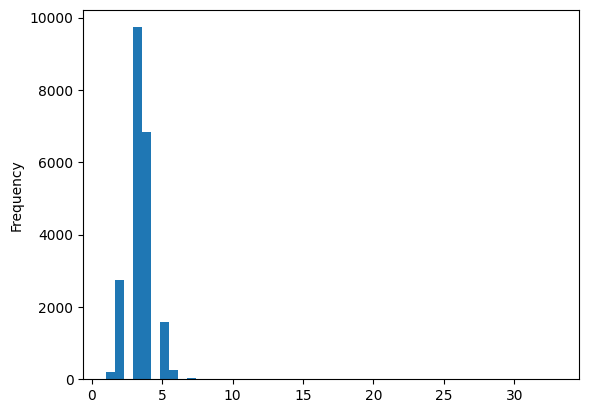

In [41]:
sorted(dfc['bedrooms'].unique()) #1,2,3,4,5,6,7,8,9,10,11 - 33 (the outlier)
dfc['bedrooms'].plot(kind='hist', bins=50)
#ah - the overwhealming majority has .. wait...

<Axes: ylabel='Frequency'>

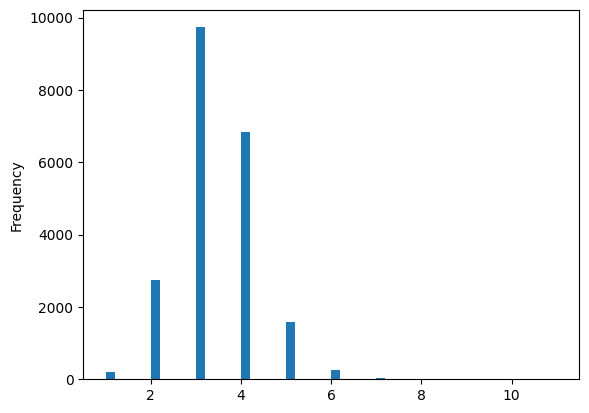

In [42]:
dfc['bedrooms'].plot(kind='hist', bins=50, range=(1,11)) #there. Better. 
#3 is the normal value ... good ... and then it gets really thin... weird 

In [46]:
counts = dfc['zipcode'].value_counts()
counts.describe()
type(counts[98059])

counts.index
counts[98059]
counts.values

area_coding = {}
for zip, count in counts.items():

    if (count < 50):
        area_coding[zip] = '0_deserted'
    elif count >= 50 and count < 150:
        area_coding[zip] = '1_low'
    elif count >= 150 and count < 350:
        area_coding[zip] = '2_medium'
    elif count >= 350 and count < 500:
        area_coding[zip] = '3_lively'
    elif count > 500:
        area_coding[zip] =  '4_crowded'
    else:
        print('something went wrong')


area_coding[98059]
len(area_coding)

70

In [ ]:
dfc['area_quality'] = dfc['zipcode']
dfc['area_quality']=


0    98178
1    98125
2    98028
3    98136
4    98074
Name: area_quality, dtype: int64

In [ ]:
dfc['zipcode_count'] = counts[dfc.loc['zipcode']]
dfc['zipcode_count'][0]

KeyError: 'zipcode'

In [ ]:
dfc['zipcode_count'] = dfc['zipcode'].value_counts()

conditions = [
    (dfc['zipcode] < 50'),
    (dfc['zipcode_count'].value_counts() >= 50) & (dfc['zipcode'].value_counts() < 150),
    (dfc['zipcode'].value_counts() >= 150) & (dfc['zipcode'].value_counts() < 350),
    (dfc['zipcode'].value_counts() >= 350) & (dfc['zipcode'].value_counts() < 500),
    (dfc['zipcode'].value_counts() > 500),

]
choices = [
    '0_deserted',
    '1_low',
    '2_medium',
    '3_lively',
    '4_crowded'
]
dfc['zipcode_status'] = np.select(conditions, choices, default='error')
dfc['zipcode_status'].unique()

In [ ]:
#now with the zipcodes
#500, 530, 150 (take 50 for good measure)
#I want to write a new column, where it says something categorical for the zipcode-properties. 

conditions = [
    (dfc['zipcode'].value_counts() < 50),
    (dfc['zipcode'].value_counts() >= 50) & (dfc['zipcode'].value_counts() < 150),
    (dfc['zipcode'].value_counts() >= 150) & (dfc['zipcode'].value_counts() < 350),
    (dfc['zipcode'].value_counts() >= 350) & (dfc['zipcode'].value_counts() < 500),
    (dfc['zipcode'].value_counts() > 500),

]
choices = [
    '0_deserted',
    '1_low',
    '2_medium',
    '3_lively',
    '4_crowded'
]
dfc['zipcode_status'] = np.select(conditions, choices, default='error')
dfc['zipcode_status'].unique()

ValueError: Length of values (70) does not match length of index (21420)

"good" property: filter list 
* waterfront
* grade of 10 or above (luxury!) (8 or above is good)
* view is 3 or above 
* bedrooms between 3 and 8
* (renovated (there my insight maybe)) * ! recently! renovated OR recently built 
* ok fair - limit the zipcodes to "not crowded" and "not empty" 

Decision matrix: 
it COULD be great, if...
* it had a (large enough) lot 
* it was historic 
* show off means - the surroundings are worse than theirs 

- "great neighborhood" 
- "close to great sites" 

: all of these give POINTS 
: historic gives extra point 
